In [1]:
%matplotlib inline

# 	神经网络实验

## 实验目的
掌握BP神经网络的原理和学习算法。

## 实验要求
编程实现N层BP神经网络算法。

## 实验内容1
阅读并理解以下代码。

Epoch 1:
Train loss: 0.9887, Train accuracy: 0.3538
Test loss: 0.9599, Test accuracy: 0.3800
Epoch 2:
Train loss: 0.9448, Train accuracy: 0.3538
Test loss: 0.9178, Test accuracy: 0.3800
Epoch 3:
Train loss: 0.9046, Train accuracy: 0.3538
Test loss: 0.8794, Test accuracy: 0.3800
Epoch 4:
Train loss: 0.8679, Train accuracy: 0.3538
Test loss: 0.8444, Test accuracy: 0.3800
Epoch 5:
Train loss: 0.8345, Train accuracy: 0.3538
Test loss: 0.8126, Test accuracy: 0.3800
Epoch 6:
Train loss: 0.8042, Train accuracy: 0.3538
Test loss: 0.7838, Test accuracy: 0.3800
Epoch 7:
Train loss: 0.7767, Train accuracy: 0.3538
Test loss: 0.7578, Test accuracy: 0.3800
Epoch 8:
Train loss: 0.7519, Train accuracy: 0.3550
Test loss: 0.7344, Test accuracy: 0.3800
Epoch 9:
Train loss: 0.7296, Train accuracy: 0.3613
Test loss: 0.7134, Test accuracy: 0.3850
Epoch 10:
Train loss: 0.7094, Train accuracy: 0.3738
Test loss: 0.6945, Test accuracy: 0.3900
Epoch 11:
Train loss: 0.6913, Train accuracy: 0.4025
Test loss: 0.677

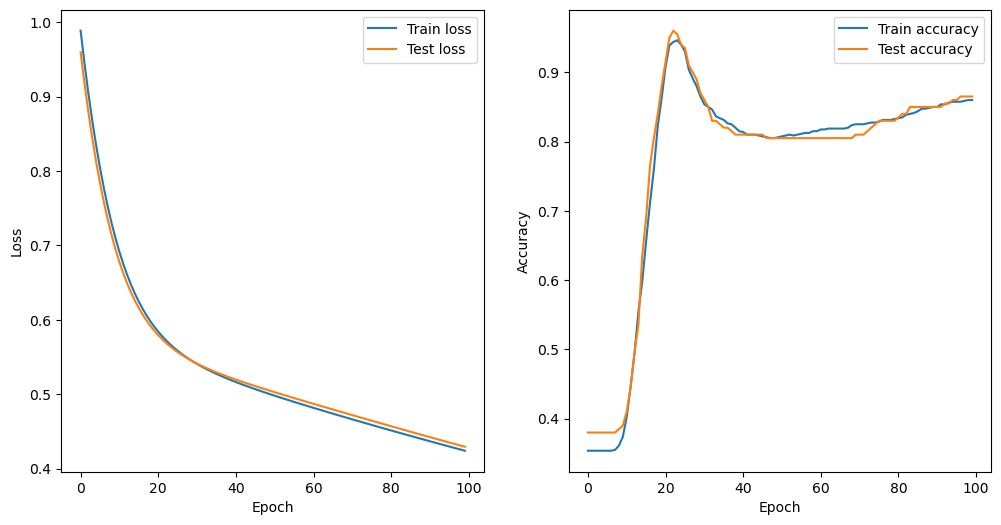

In [2]:
# 导入所需的模块
import numpy as np
import matplotlib.pyplot as plt

# 定义神经网络类
class NeuralNetwork:

    # 初始化网络结构和参数
    def __init__(self, input_size, hidden_size, output_size, learning_rate):
        self.input_size = input_size # 输入层节点数
        self.hidden_size = hidden_size # 隐藏层节点数
        self.output_size = output_size # 输出层节点数
        self.learning_rate = learning_rate # 学习率
        self.W1 = np.random.randn(hidden_size, input_size) # 输入层到隐藏层的权重矩阵
        self.b1 = np.random.randn(hidden_size, 1) # 隐藏层的偏置向量
        self.W2 = np.random.randn(output_size, hidden_size) # 隐藏层到输出层的权重矩阵
        self.b2 = np.random.randn(output_size, 1) # 输出层的偏置向量

    # 定义激活函数和其导数
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return self.sigmoid(x) * (1 - self.sigmoid(x))

    # 定义前向传播函数，计算网络的输出
    def forward(self, X):
        Z1 = self.W1.dot(X) + self.b1 # 隐藏层的线性组合
        A1 = self.sigmoid(Z1) # 隐藏层的激活值
        Z2 = self.W2.dot(A1) + self.b2 # 输出层的线性组合
        A2 = self.sigmoid(Z2) # 输出层的激活值，即网络的输出
        return A2, A1, Z1

    # 定义反向传播函数，计算网络的梯度
    def backward(self, X, Y, A2, A1, Z1):
        m = X.shape[1] # 样本数
        dZ2 = A2 - Y # 输出层的误差项
        dW2 = (1 / m) * dZ2.dot(A1.T) # 输出层到隐藏层的权重梯度
        db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True) # 输出层的偏置梯度
        dZ1 = self.W2.T.dot(dZ2) * self.sigmoid_derivative(Z1) # 隐藏层的误差项
        dW1 = (1 / m) * dZ1.dot(X.T) # 输入层到隐藏层的权重梯度
        db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True) # 隐藏层的偏置梯度
        return dW2, db2, dW1, db1

    # 定义更新函数，根据梯度更新网络参数
    def update(self, dW2, db2, dW1, db1):
        self.W2 = self.W2 - self.learning_rate * dW2 # 更新输出层到隐藏层的权重
        self.b2 = self.b2 - self.learning_rate * db2 # 更新输出层的偏置
        self.W1 = self.W1 - self.learning_rate * dW1 # 更新输入层到隐藏层的权重
        self.b1 = self.b1 - self.learning_rate * db1 # 更新隐藏层的偏置

    # 定义损失函数，计算网络的损失值
    def loss(self, Y, A2):
        m = Y.shape[1] # 样本数
        L = -(Y * np.log(A2) + (1 - Y) * np.log(1 - A2)) # 交叉熵损失函数
        J = (1 / m) * np.sum(L) # 平均损失值
        return J
 

    # 定义训练函数，对网络进行训练和测试
    def train(self, X_train, Y_train, X_test, Y_test, epochs):
        # 初始化损失值和准确率的列表，用于记录训练过程
        train_loss = []
        train_acc = []
        test_loss = []
        test_acc = []

        # 进行指定轮数的训练
        for epoch in range(epochs):
            # 前向传播，计算网络的输出
            A2_train, A1_train, Z1_train = self.forward(X_train)
            A2_test, A1_test, Z1_test = self.forward(X_test)

            # 反向传播，计算网络的梯度
            dW2, db2, dW1, db1 = self.backward(X_train, Y_train, A2_train, A1_train, Z1_train)

            # 更新网络参数
            self.update(dW2, db2, dW1, db1)

            # 计算网络的损失值
            J_train = self.loss(Y_train, A2_train)
            J_test = self.loss(Y_test, A2_test)

            # 计算网络的准确率
            Y_pred_train = np.round(A2_train) # 对输出层的激活值进行四舍五入，得到预测值
            Y_pred_test = np.round(A2_test)
            acc_train = np.mean(Y_pred_train == Y_train) # 计算预测值和真实值的一致性，得到准确率
            acc_test = np.mean(Y_pred_test == Y_test)

            # 将损失值和准确率添加到列表中
            train_loss.append(J_train)
            train_acc.append(acc_train)
            test_loss.append(J_test)
            test_acc.append(acc_test)

            # 打印每轮训练的结果
            print(f"Epoch {epoch + 1}:")
            print(f"Train loss: {J_train:.4f}, Train accuracy: {acc_train:.4f}")
            print(f"Test loss: {J_test:.4f}, Test accuracy: {acc_test:.4f}")

        # 绘制损失值和准确率的变化曲线
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.plot(train_loss, label="Train loss")
        plt.plot(test_loss, label="Test loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(train_acc, label="Train accuracy")
        plt.plot(test_acc, label="Test accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

# 创建一个神经网络对象，指定输入层、隐藏层、输出层的节点数和学习率
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=0.1)

# 生成一些模拟数据，用于训练和测试
X = np.random.randn(2, 1000) # 生成1000个二维特征向量作为输入数据
Y = np.where(X[0] + X[1] > 0.5 , 1 , 0).reshape(1,-1) # 根据输入数据的和生成对应的标签，作为输出数据

# 划分训练集和测试集，按照8:2的比例
train_size = int(0.8 * X.shape[1]) # 训练集的大小
X_train = X[:, :train_size] # 前80%的数据作为训练集
Y_train = Y[:, :train_size]
X_test = X[:, train_size:] # 后20%的数据作为测试集
Y_test = Y[:, train_size:]

# 调用训练函数，对网络进行训练和测试，指定训练轮数为100
nn.train(X_train, Y_train, X_test, Y_test, epochs=100)

## 上机内容2

1. 阅读相关资料，了解BP神经网络的原理和算法。
1. 设计一个3层BP神经网络，确定输入层、隐藏层和输出层的节点数，以及激活函数和误差函数的选择。
1. 编写代码，实现网络的初始化、前向传播、反向传播和权值更新等功能。**要求模块化设计代码，可以通过参数调节网络层数、宽度等。**
1. 选择iris数据集，对网络进行训练和测试，记录网络的误差变化和准确率变化，**提高网络在测试集的准确率。**
1. 修改网络的参数，重复上一步步骤，比较不同参数下的网络性能。
1. 撰写实验报告，总结实验结果和心得体会。

训练集大小: 105, 测试集大小: 45
输入特征: 4, 输出类别: 3

实验1: 单隐藏层网络 [4, 8, 3]，sigmoid激活
Epoch 100: Train Loss=0.0492, Train Acc=0.9905, Test Loss=0.1038, Test Acc=0.9556
Epoch 200: Train Loss=0.0291, Train Acc=0.9905, Test Loss=0.1387, Test Acc=0.9111
Epoch 300: Train Loss=0.0221, Train Acc=1.0000, Test Loss=0.1833, Test Acc=0.9111
Epoch 400: Train Loss=0.0179, Train Acc=1.0000, Test Loss=0.2073, Test Acc=0.9111
Epoch 500: Train Loss=0.0147, Train Acc=1.0000, Test Loss=0.2248, Test Acc=0.9111

最终训练准确率: 1.0000
最终测试准确率: 0.9111

实验2: 双隐藏层网络 [4, 16, 8, 3]，ReLU激活
Epoch 100: Train Loss=0.0134, Train Acc=1.0000, Test Loss=0.2069, Test Acc=0.9333
Epoch 200: Train Loss=0.0016, Train Acc=1.0000, Test Loss=0.2523, Test Acc=0.9333
Epoch 300: Train Loss=0.0008, Train Acc=1.0000, Test Loss=0.2912, Test Acc=0.9333
Epoch 400: Train Loss=0.0005, Train Acc=1.0000, Test Loss=0.3250, Test Acc=0.9333
Epoch 500: Train Loss=0.0003, Train Acc=1.0000, Test Loss=0.3505, Test Acc=0.9333

最终训练准确率: 1.0000
最终测试准确率: 0.9333

实验3: 三隐

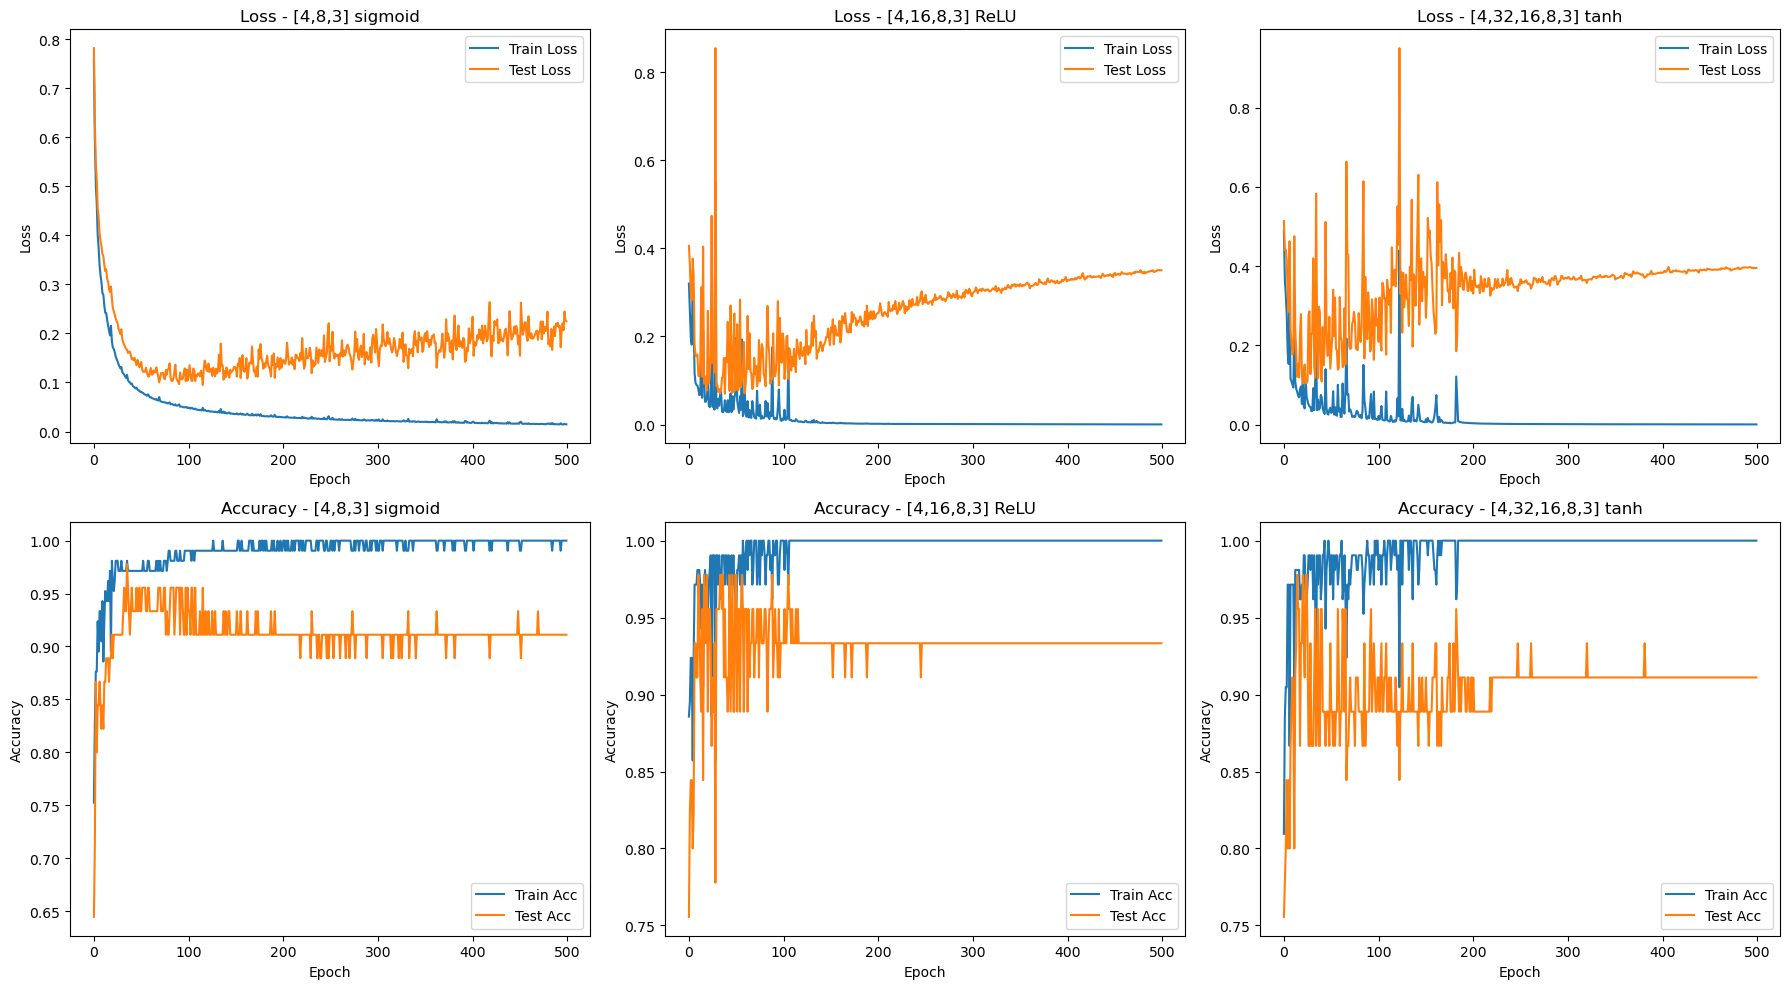


实验结果汇总
网络结构                      激活函数         训练准确率        测试准确率       
------------------------------------------------------------
[4, 8, 3]                 sigmoid      1.0000       0.9111      
[4, 16, 8, 3]             ReLU         1.0000       0.9333      
[4, 32, 16, 8, 3]         tanh         1.0000       0.9111      

最佳模型: [4,16,8,3]+ReLU, 测试准确率: 0.9333

实验心得：
1. 模块化设计使得网络结构（层数、宽度、激活函数）可以灵活配置
2. ReLU激活函数在较深网络中比sigmoid表现更好，避免了梯度消失问题
3. 适当增加隐藏层和神经元数量可以提高模型表达能力
4. 但网络过于复杂也可能导致过拟合，需要在训练集和测试集上平衡
5. 标准化输入数据对神经网络训练至关重要，能加速收敛
6. Mini-batch训练相比全量梯度下降更稳定，收敛更快
7. 交叉熵+Softmax是处理多分类问题的标准组合


In [3]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# ============================================================
# 模块化N层BP神经网络实现
# 支持：可配置层数/宽度、多种激活函数、mini-batch训练
# ============================================================

class NLayerNN:
    """
    N层BP神经网络（模块化设计）
    参数:
        layer_sizes: 各层神经元数量列表，如 [4, 16, 8, 3] 表示输入4→隐藏16→隐藏8→输出3
        activations: 各隐藏层的激活函数名列表，支持 'sigmoid', 'tanh', 'relu'
        learning_rate: 学习率
        random_state: 随机种子
    """

    def __init__(self, layer_sizes, activations=None, learning_rate=0.1, random_state=42):
        self.layer_sizes = layer_sizes
        self.L = len(layer_sizes) - 1  # 权值矩阵层数
        self.lr = learning_rate
        np.random.seed(random_state)

        # 默认所有隐藏层使用sigmoid激活
        if activations is None:
            activations = ['sigmoid'] * (self.L - 1)
        self.activations = activations  # 隐藏层激活函数

        # 初始化参数 (He初始化用于ReLU, Xavier用于sigmoid/tanh)
        self.W = []  # 权值矩阵列表
        self.b = []  # 偏置向量列表
        for l in range(self.L):
            fan_in = layer_sizes[l]
            fan_out = layer_sizes[l + 1]
            if l < self.L - 1 and activations[l] == 'relu':
                scale = np.sqrt(2.0 / fan_in)  # He初始化
            else:
                scale = np.sqrt(1.0 / fan_in)  # Xavier初始化
            Wl = np.random.randn(fan_out, fan_in) * scale
            bl = np.zeros((fan_out, 1))
            self.W.append(Wl)
            self.b.append(bl)

    # -------- 激活函数 --------
    def _activation(self, z, name):
        if name == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-z))
        elif name == 'tanh':
            return np.tanh(z)
        elif name == 'relu':
            return np.maximum(0, z)

    def _activation_derivative(self, a, name):
        if name == 'sigmoid':
            return a * (1 - a)
        elif name == 'tanh':
            return 1 - a ** 2
        elif name == 'relu':
            return (a > 0).astype(float)

    def _softmax(self, z):
        z_stable = z - np.max(z, axis=0, keepdims=True)
        exp_z = np.exp(z_stable)
        return exp_z / np.sum(exp_z, axis=0, keepdims=True)

    # -------- 前向传播 --------
    def forward(self, X):
        """X shape: (n_features, n_samples)"""
        self.Z = []  # 各层线性输出（激活前）
        self.A = [X]  # 各层激活值，A[0]=输入

        A_cur = X
        for l in range(self.L - 1):
            Zl = self.W[l].dot(A_cur) + self.b[l]
            Al = self._activation(Zl, self.activations[l])
            self.Z.append(Zl)
            self.A.append(Al)
            A_cur = Al

        # 输出层: softmax
        ZL = self.W[-1].dot(A_cur) + self.b[-1]
        AL = self._softmax(ZL)
        self.Z.append(ZL)
        self.A.append(AL)

        return AL

    # -------- 反向传播 --------
    def backward(self, Y):
        """
        Y shape: (n_classes, n_samples) one-hot编码
        使用交叉熵 + softmax的联合梯度
        """
        m = Y.shape[1]
        grads_W = []
        grads_b = []

        # 输出层误差: softmax+交叉熵的梯度 = A_L - Y
        dZ = self.A[-1] - Y  # (n_classes, m)
        for l in range(self.L - 1, -1, -1):
            dW = (1.0 / m) * dZ.dot(self.A[l].T)
            db = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
            grads_W.insert(0, dW)
            grads_b.insert(0, db)

            if l > 0:
                dA = self.W[l].T.dot(dZ)
                dZ = dA * self._activation_derivative(self.A[l], self.activations[l - 1])

        return grads_W, grads_b

    # -------- 参数更新 --------
    def update(self, grads_W, grads_b):
        for l in range(self.L):
            self.W[l] -= self.lr * grads_W[l]
            self.b[l] -= self.lr * grads_b[l]

    # -------- 损失函数 --------
    def loss(self, Y, Y_pred):
        """交叉熵损失"""
        m = Y.shape[1]
        eps = 1e-15
        Y_pred = np.clip(Y_pred, eps, 1 - eps)
        return -np.sum(Y * np.log(Y_pred)) / m

    # -------- 预测 --------
    def predict(self, X):
        proba = self.forward(X)
        return np.argmax(proba, axis=0)

    # -------- 训练 --------
    def fit(self, X_train, Y_train, X_test, Y_test, epochs=500, batch_size=32, verbose=True):
        """
        训练网络
        参数:
            X_train, Y_train: 训练数据 (n_features, n_samples), (n_classes, n_samples)
            X_test, Y_test: 测试数据
            epochs: 训练轮数
            batch_size: mini-batch大小
            verbose: 是否打印训练过程
        """
        n_samples = X_train.shape[1]
        history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

        for epoch in range(epochs):
            # Mini-batch训练
            indices = np.random.permutation(n_samples)
            for start in range(0, n_samples, batch_size):
                batch_idx = indices[start:start + batch_size]
                X_batch = X_train[:, batch_idx]
                Y_batch = Y_train[:, batch_idx]

                Y_pred_batch = self.forward(X_batch)
                grads_W, grads_b = self.backward(Y_batch)
                self.update(grads_W, grads_b)

            # 每个epoch评估一次
            Y_pred_train = self.forward(X_train)
            Y_pred_test = self.forward(X_test)

            train_loss = self.loss(Y_train, Y_pred_train)
            test_loss = self.loss(Y_test, Y_pred_test)

            train_acc = np.mean(np.argmax(Y_pred_train, axis=0) == np.argmax(Y_train, axis=0))
            test_acc = np.mean(np.argmax(Y_pred_test, axis=0) == np.argmax(Y_test, axis=0))

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['test_loss'].append(test_loss)
            history['test_acc'].append(test_acc)

            if verbose and (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
                      f"Test Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")

        return history


# ============================================================
# 数据准备：加载Iris数据集
# ============================================================
X, y = load_iris(return_X_y=True)

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot编码标签
encoder = OneHotEncoder(sparse_output=False)
Y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# 划分训练集和测试集 (7:3)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y_onehot, test_size=0.3, random_state=42, stratify=y
)

# 转置为 (n_features, n_samples) 格式
X_train_T = X_train.T  # (4, 105)
Y_train_T = y_train.T   # (3, 105)
X_test_T = X_test.T     # (4, 45)
Y_test_T = y_test.T     # (3, 45)

print(f"训练集大小: {X_train_T.shape[1]}, 测试集大小: {X_test_T.shape[1]}")
print(f"输入特征: {X_train_T.shape[0]}, 输出类别: {Y_train_T.shape[0]}")


# ============================================================
# 实验1：基础网络 [4, 8, 3]，sigmoid激活
# ============================================================
print("\n" + "="*60)
print("实验1: 单隐藏层网络 [4, 8, 3]，sigmoid激活")
print("="*60)

nn1 = NLayerNN(layer_sizes=[4, 8, 3], activations=['sigmoid'],
               learning_rate=0.5, random_state=42)
history1 = nn1.fit(X_train_T, Y_train_T, X_test_T, Y_test_T,
                    epochs=500, batch_size=16)

final_train_acc = history1['train_acc'][-1]
final_test_acc = history1['test_acc'][-1]
print(f"\n最终训练准确率: {final_train_acc:.4f}")
print(f"最终测试准确率: {final_test_acc:.4f}")


# ============================================================
# 实验2：双隐藏层网络 [4, 16, 8, 3]，relu激活
# ============================================================
print("\n" + "="*60)
print("实验2: 双隐藏层网络 [4, 16, 8, 3]，ReLU激活")
print("="*60)

nn2 = NLayerNN(layer_sizes=[4, 16, 8, 3], activations=['relu', 'relu'],
               learning_rate=0.3, random_state=42)
history2 = nn2.fit(X_train_T, Y_train_T, X_test_T, Y_test_T,
                    epochs=500, batch_size=16)

final_train_acc2 = history2['train_acc'][-1]
final_test_acc2 = history2['test_acc'][-1]
print(f"\n最终训练准确率: {final_train_acc2:.4f}")
print(f"最终测试准确率: {final_test_acc2:.4f}")


# ============================================================
# 实验3：更深网络 [4, 32, 16, 8, 3]，tanh激活
# ============================================================
print("\n" + "="*60)
print("实验3: 三隐藏层网络 [4, 32, 16, 8, 3]，tanh激活")
print("="*60)

nn3 = NLayerNN(layer_sizes=[4, 32, 16, 8, 3], activations=['tanh', 'tanh', 'tanh'],
               learning_rate=0.3, random_state=42)
history3 = nn3.fit(X_train_T, Y_train_T, X_test_T, Y_test_T,
                    epochs=500, batch_size=16)

final_train_acc3 = history3['train_acc'][-1]
final_test_acc3 = history3['test_acc'][-1]
print(f"\n最终训练准确率: {final_train_acc3:.4f}")
print(f"最终测试准确率: {final_test_acc3:.4f}")


# ============================================================
# 可视化：比较三种网络结构的训练过程
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 损失曲线
for ax, hist, title in zip(axes[0],
                           [history1, history2, history3],
                           ['[4,8,3] sigmoid', '[4,16,8,3] ReLU', '[4,32,16,8,3] tanh']):
    ax.plot(hist['train_loss'], label='Train Loss')
    ax.plot(hist['test_loss'], label='Test Loss')
    ax.set_title(f'Loss - {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

# 准确率曲线
for ax, hist, title in zip(axes[1],
                           [history1, history2, history3],
                           ['[4,8,3] sigmoid', '[4,16,8,3] ReLU', '[4,32,16,8,3] tanh']):
    ax.plot(hist['train_acc'], label='Train Acc')
    ax.plot(hist['test_acc'], label='Test Acc')
    ax.set_title(f'Accuracy - {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 结果汇总
# ============================================================
print("\n" + "="*60)
print("实验结果汇总")
print("="*60)
print(f"{'网络结构':<25} {'激活函数':<12} {'训练准确率':<12} {'测试准确率':<12}")
print("-"*60)
print(f"{'[4, 8, 3]':<25} {'sigmoid':<12} {history1['train_acc'][-1]:<12.4f} {history1['test_acc'][-1]:<12.4f}")
print(f"{'[4, 16, 8, 3]':<25} {'ReLU':<12} {history2['train_acc'][-1]:<12.4f} {history2['test_acc'][-1]:<12.4f}")
print(f"{'[4, 32, 16, 8, 3]':<25} {'tanh':<12} {history3['train_acc'][-1]:<12.4f} {history3['test_acc'][-1]:<12.4f}")

# 找出最佳模型
best_idx = np.argmax([history1['test_acc'][-1], history2['test_acc'][-1], history3['test_acc'][-1]])
best_names = ['[4,8,3]+sigmoid', '[4,16,8,3]+ReLU', '[4,32,16,8,3]+tanh']
print(f"\n最佳模型: {best_names[best_idx]}, 测试准确率: {[history1['test_acc'][-1], history2['test_acc'][-1], history3['test_acc'][-1]][best_idx]:.4f}")

# ============ 实验心得 ============
print("\n" + "="*60)
print("实验心得：")
print("1. 模块化设计使得网络结构（层数、宽度、激活函数）可以灵活配置")
print("2. ReLU激活函数在较深网络中比sigmoid表现更好，避免了梯度消失问题")
print("3. 适当增加隐藏层和神经元数量可以提高模型表达能力")
print("4. 但网络过于复杂也可能导致过拟合，需要在训练集和测试集上平衡")
print("5. 标准化输入数据对神经网络训练至关重要，能加速收敛")
print("6. Mini-batch训练相比全量梯度下降更稳定，收敛更快")
print("7. 交叉熵+Softmax是处理多分类问题的标准组合")
print("="*60)